# Temporal Plots

In [2]:
import json

import pandas as pd
import matplotlib.pyplot as plt

## Config

In [3]:
dataset = "aitv2"
scenario = "santos"

In [4]:
model = "multiclass"
features = "aug"
subset = "full"
window_size = "w100"

## Load data

In [24]:
processed_dir = f"../data/processed/{dataset}/{scenario}/windowed"
metrics_dir = f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics"

exp_name = f"{model}_{features}_{window_size}_{subset}"
metrics_file = f"{metrics_dir}/{exp_name}.json"

In [25]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{scenario}/flows_labeled/flows_augmented.csv"
)
df = df.sort_values("start_time").reset_index(drop=True)
df['start_time_dt'] = df['start_time'] - df['start_time'].min()

In [ ]:
df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")
df["end_time_dt"] = pd.to_datetime(df["end_time_dt"], errors="coerce")
phase_bounds = (
    df.
    groupby("phase", sort=True)["start_time_dt"]
      .agg(["min", "max"])
)

phase_start = phase_bounds['min'].to_dict()
phase_end   = phase_bounds['max'].to_dict()

phase_bounds

,min,max
phase,,
0,2022-01-14 00:00:02.447540045,2022-01-17 23:59:53.847025156
1,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
2,2022-01-17 11:15:12.901682854,2022-01-17 11:23:23.407361984
3,2022-01-17 11:23:00.334776878,2022-01-17 11:24:14.355878115
4,2022-01-17 11:24:32.617721081,2022-01-17 11:57:33.454643965


## Create DF with Misclassified Samples

In [43]:
with open(metrics_file) as f:
    metrics = json.load(f)

real_flow_indices = metrics["real_flow_indices"]
mis_df = df.iloc[real_flow_indices].copy()
mis_df["y_true"] = metrics["y_true"]
mis_df["y_pred"] = metrics["y_pred"]

In [44]:
def is_hard_violation(row, phase_start):
    pred_phase = row['y_pred']
    t = row['start_time_dt']

    if pred_phase == 0 or pred_phase == 1:
        return False
    
    prev_phase = pred_phase - 1
    
    if prev_phase in phase_start:
        if t < phase_start[prev_phase]:
            return True

    return False


def is_soft_violation(row, phase_start):
    pred_phase = row['y_pred']
    t = row['start_time_dt']

    if pred_phase == 0:
        return False

    next_phase = pred_phase + 1

    if next_phase in phase_start:
        if t >= phase_start[next_phase]:
            return True

    return False


def mis_metrics(mis_df, phase_start):

    mis_df["start_time_dt"] = pd.to_datetime(mis_df["start_time_dt"], errors="coerce")
    mis_df["end_time_dt"]   = pd.to_datetime(mis_df["end_time_dt"],   errors="coerce")
    
    mis_df['hard_violation'] = mis_df.apply(
        is_hard_violation,
        axis=1,
        phase_start=phase_start
    )

    mis_df['soft_violation'] = mis_df.apply(
        is_soft_violation,
        axis=1,
        phase_start=phase_start
    )

    wrong_df = mis_df[mis_df['phase'] != mis_df['y_pred']]

    hard_df = wrong_df[wrong_df['hard_violation']]
    soft_df = wrong_df[(~wrong_df['hard_violation']) & (wrong_df['soft_violation'])]
    plausible_df = wrong_df[(~wrong_df['hard_violation']) & (~wrong_df['soft_violation'])]

    return wrong_df, hard_df, soft_df, plausible_df


def temp_metrics(f1, wrong, hard, soft):

    total_wrong = len(wrong)
    hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
    soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

    temp_score = f1 - 0.5 * hard_rate - 0.2 * soft_rate

    return hard_rate, soft_rate, temp_score 

In [45]:
wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)
hard_rate, soft_rate, temp_score = temp_metrics(metrics["Macro F1"], wrong, hard, soft)

total_wrong = len(wrong)
print(f"Total wrong: {total_wrong}")
print(f"Hard violations: {len(hard)} ({hard_rate:.2%})")
print(f"Soft violations: {len(soft)} ({soft_rate:.2%})")
print(f"Wrong but plausible: {len(plausible)}")

Total wrong: 271
Hard violations: 24 (8.86%)
Soft violations: 233 (85.98%)
Wrong but plausible: 14


In [50]:
def plot_mis_predictions(
    df, phase_bounds, 
    plausible, soft, hard, 
    exp_name, out_dir,
    save_plot=True, show_plot=True,
    attack_start=None, attack_end=None,
):

    # --- Optionally trim DF ---
    if attack_start is not None and attack_end is not None:
        df = df.copy()
        df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")
        df["end_time_dt"]   = pd.to_datetime(df["end_time_dt"],   errors="coerce")
        df = df[(df["start_time_dt"] >= attack_start) & (df["end_time_dt"] <= attack_end)]
        
        plausible = plausible[(plausible["start_time_dt"] >= attack_start) & (plausible["end_time_dt"] <= attack_end)]
        soft      = soft[(soft["start_time_dt"] >= attack_start) & (soft["end_time_dt"] <= attack_end)]
        hard      = hard[(hard["start_time_dt"] >= attack_start) & (hard["end_time_dt"] <= attack_end)]


    fig, ax = plt.subplots(figsize=(14, 5))

    edges  = phase_bounds["min"].tolist() + [phase_bounds["max"].iloc[-1]]
    values = phase_bounds.index.tolist()

    ax.stairs(
        values=values,
        edges=edges,
        linewidth=1,
        color="black",
        label="True phase"
    )

    values.append(5)
    ax.fill_between(
        edges,                    
        values,              
        [min(values) - 0.5]*len(values),  
        step="post",
        color="lightgray",
        alpha=0.2
    )

    ax.scatter(plausible["start_time_dt"], plausible["y_pred"], s=70, marker="X",
               color="purple", alpha=0.9, label="Temporal‑plausible errors")

    ax.scatter(soft["start_time_dt"], soft["y_pred"], s=70, marker="X",
               color="orange", alpha=0.9, label="Regression violations")

    ax.scatter(hard["start_time_dt"], hard["y_pred"], s=70, marker="X",
               color="red", alpha=0.9, label="Causal violations")

    ax.set_ylim(-0.5, max(values) + 2)
    ax.set_xlim(df["start_time_dt"].min(), df["start_time_dt"].max())
    ax.set_xlabel("Relative time")
    ax.set_ylabel("Phase")
    ax.set_title(f"Temporal Consistency - Prediction Violations")
    ax.set_yticks(sorted(df["phase"].unique()))
    ax.grid(alpha=0.2)

    ax.legend(
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        loc="upper right"
    )


    fig.tight_layout()

    if save_plot:
        out_path = out_dir / f"{exp_name}.png"
        print(f"Saving plot to {out_path}...")
        fig.savefig(out_path, dpi=300, bbox_inches="tight")

    if show_plot:
        plt.show()


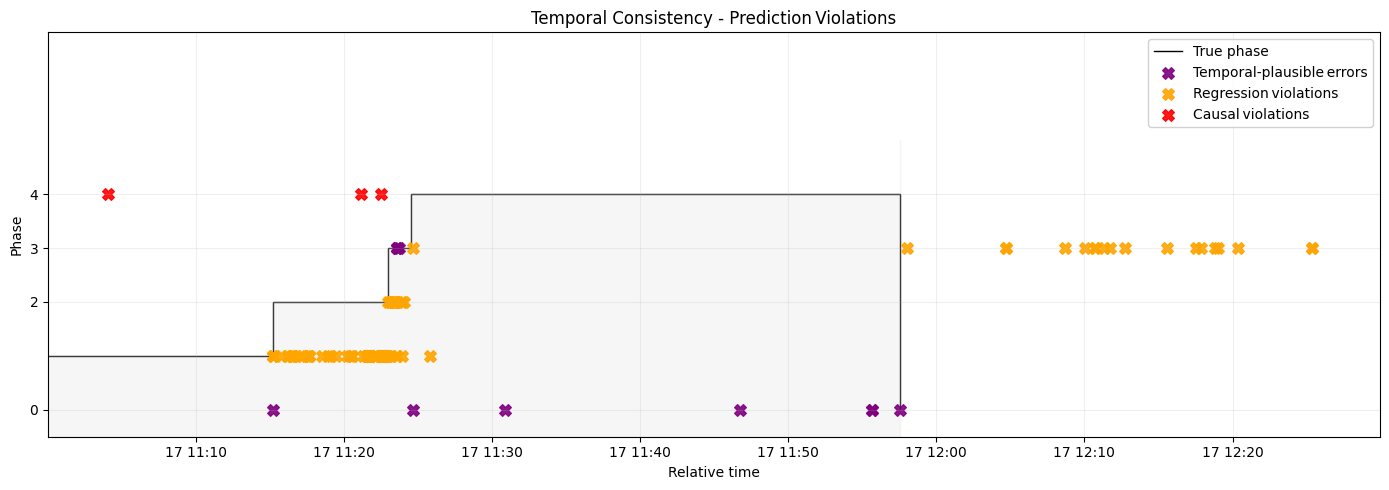

In [ ]:
# santos
# attack_start = pd.Timestamp("2022-01-17 11:15")
# attack_end   = pd.Timestamp("2022-01-17 11:59")

attack_start = pd.Timestamp("2022-01-17 11:00")
attack_end   = pd.Timestamp("2022-01-17 12:00")

plot_mis_predictions(
    df, phase_bounds, 
    plausible, soft, hard, 
    exp_name=exp_name, 
    out_dir = "",
    attack_start=attack_start,
    attack_end=attack_end,
    save_plot=False
)


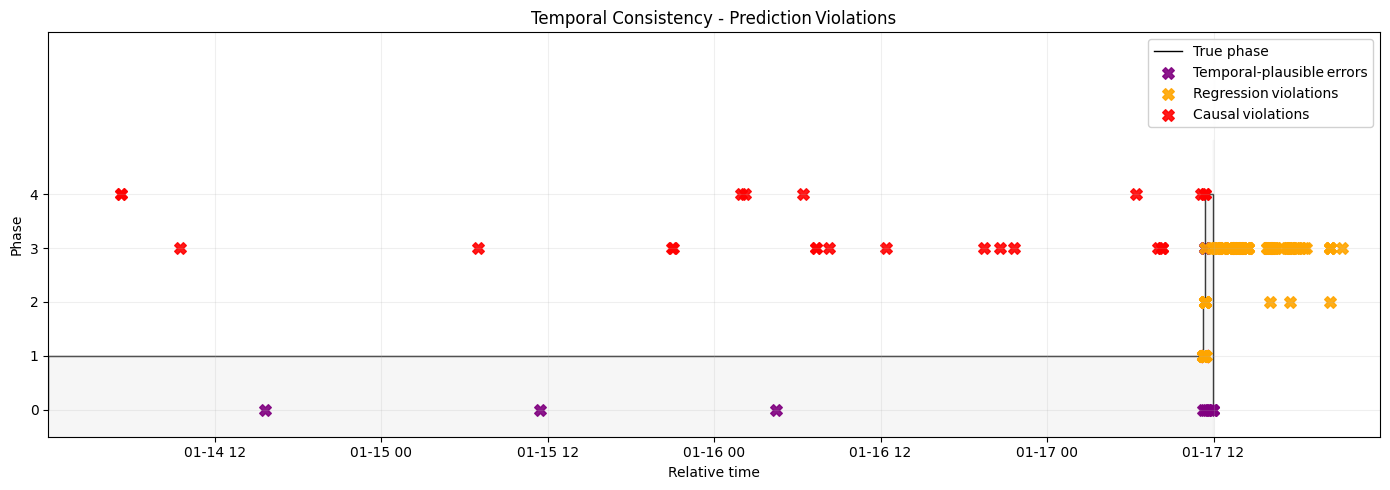

In [52]:
plot_mis_predictions(
    df, phase_bounds, 
    plausible, soft, hard,
    exp_name=exp_name, 
    out_dir = "",
    attack_start=None,
    attack_end=None,
    save_plot=False
)
